In [39]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from sklearn import metrics

import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import pairwise_distances

import seaborn as sns
import sys
import math
from sklearn.gaussian_process.kernels import RBF
from mmd_critic import MMDCritic
from mmd_critic.kernels import RBFKernel
from FALCON.FALCON import FALCON



from sklearn.neighbors import NearestNeighbors
from scipy.linalg import eigh

def adaptive_rbf_kernel(X, k=None, alpha=1.0, smooth=True,
                        clip_percentiles=(15,85), make_psd=True, eps=1e-10):
    """
    Compute an adaptive RBF kernel matrix K for data X with local bandwidths.
    - X: (n_samples, n_features)
    - k: neighbors used to estimate local scale. Default: max(5, min(50, int(0.02*n)))
    - alpha: multiplicative scale for sigma_i
    - smooth: median smoothing of sigma over k-neighbors
    - clip_percentiles: (low, high) percentiles to clip sigma to
    - make_psd: if True, perform eigenvalue clipping to make K PSD
    - eps: small value to avoid division by zero
    Returns:
    - K: (n,n) kernel matrix
    - sigma: (n,) local bandwidths
    """
    n, d = X.shape
    if k is None:
        k = max(5, min(200, int(0.1 * n)))
    k = min(k, n-1)

    # 1) k-NN distances
    nn = NearestNeighbors(n_neighbors=k+1).fit(X)  # include self
    dists, idx = nn.kneighbors(X)                 # dists[:,0] == 0 (self)
 
    kth_dist = dists[:, -1]                                   

    # 2) raw sigma
    sigma = alpha * (kth_dist + eps)

    # 3) optional smoothing (median of neighbor sigmas)
    if smooth:
        neigh_sigma = sigma[idx[:, 1:]]  # exclude self
        sigma = np.median(np.concatenate([sigma.reshape(-1,1), neigh_sigma], axis=1), axis=1)

    # 4) clipping to avoid extremes
    lo, hi = np.percentile(sigma, [clip_percentiles[0], clip_percentiles[1]])
    sigma = np.clip(sigma, lo + eps, hi + eps)

    # 5) pairwise squared distances (could be optimized / approximated)
    sq = np.sum(X**2, axis=1, keepdims=True)
    d2 = sq + sq.T - 2 * (X @ X.T)
    d2 = np.maximum(d2, 0.0)

    # 6) build kernel with geometric-mean sigma_ij = sqrt(sigma_i*sigma_j)
    Sigma = np.outer(sigma, sigma)
    denom = 2.0 * Sigma + eps
    K = np.exp(- d2 / denom)

    # 7) optional PSD correction (eigenvalue clipping)
    if make_psd:
        # compute symmetric eigen-decomposition
        vals, vecs = eigh(K)
        vals_clipped = np.clip(vals, a_min=0.0, a_max=None)
        K = (vecs * vals_clipped) @ vecs.T

    return K

In [40]:
X,y = open_dataset('2d-4c-no4')

In [41]:
n, d = X.shape
K_adp =adaptive_rbf_kernel(X)
sigma = np.sqrt(np.median(pairwise_distances(X,X))) 
K_median = RBFKernel(sigma)(X)
K_best = RBFKernel(0.05)(X)

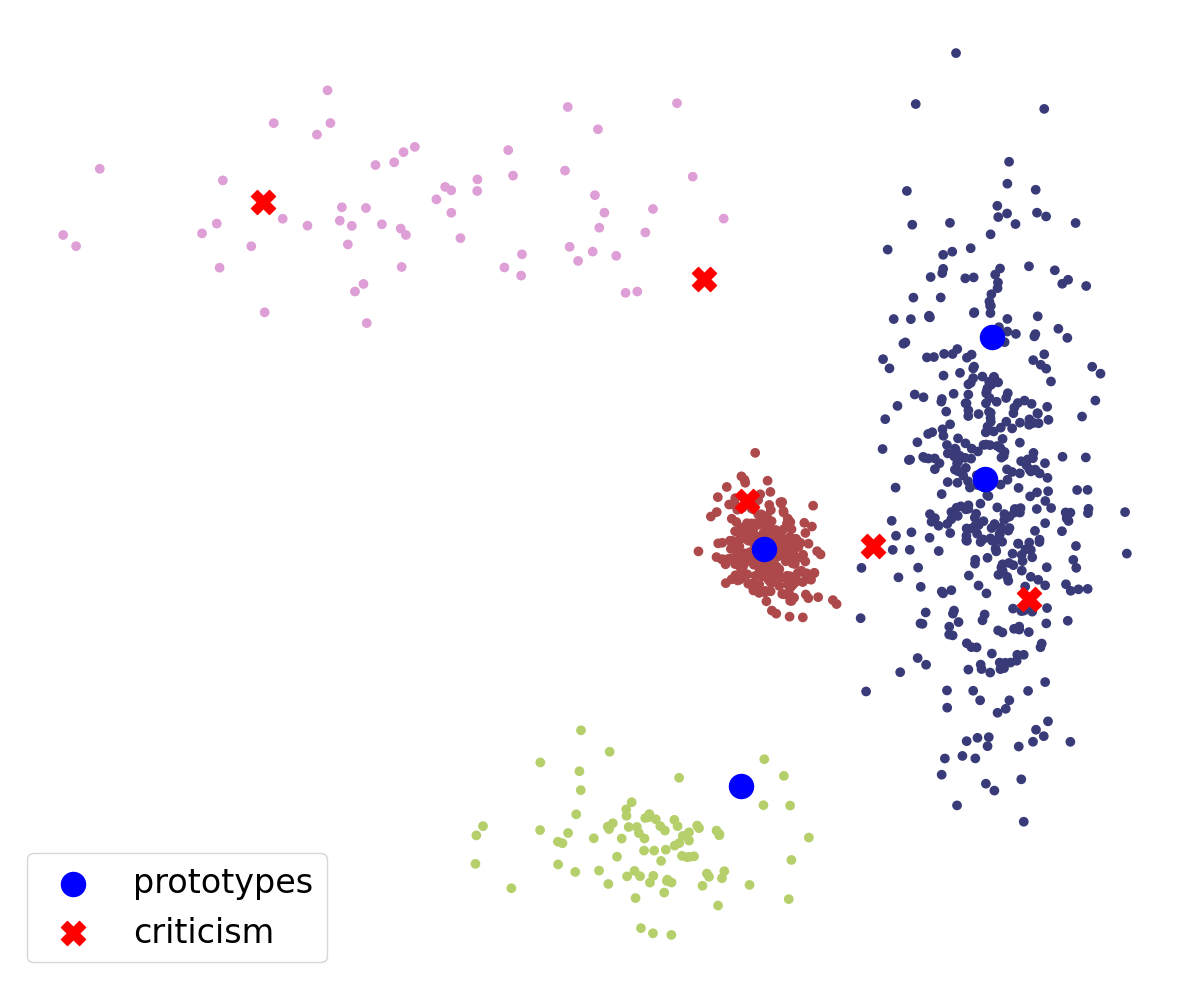

In [42]:
n = 4
MMD = MMDCritic(X,adaptive_rbf_kernel)
k_proto = MMD.select_prototypes(n, np.arange(len(X)))
k_criti = MMD.select_criticisms(n+1, X[k_proto], train_indices = np.arange(len(X)), argMax = True)
plt.figure(figsize=(12,10))
plt.scatter(X[:,0],X[:,1], alpha = 1, c=y, cmap='tab20b')
plt.scatter(X[k_proto,0],X[k_proto,1], c='b', s = 300, label='prototypes')
plt.scatter(X[k_criti,0],X[k_criti,1], c='red', marker='X', s = 300, label='criticism')
plt.legend(prop={'size': 24})
plt.axis('off')
plt.tight_layout()
plt.show()

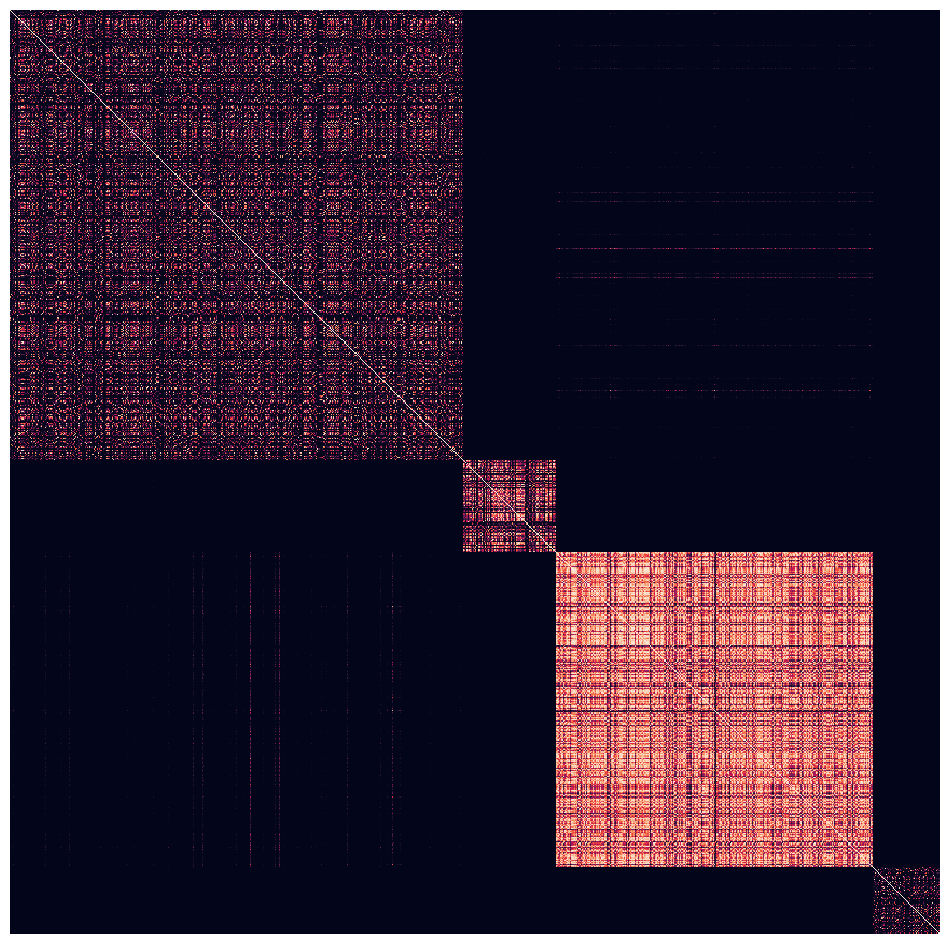

In [25]:
plt.figure(figsize=(12,12))

sns.heatmap(K_best, cbar=False)
plt.axis('off')
plt.show()

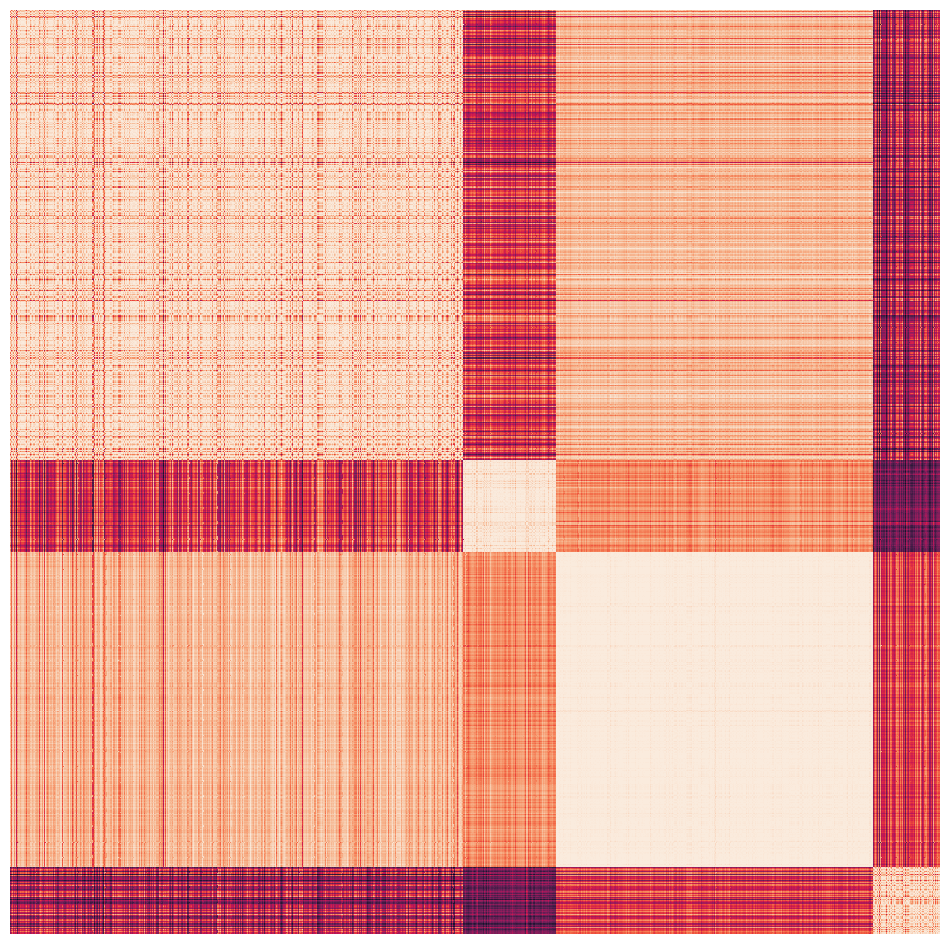

In [23]:
plt.figure(figsize=(12,12))

sns.heatmap(K_median, cbar=False)
plt.axis('off')
plt.show()

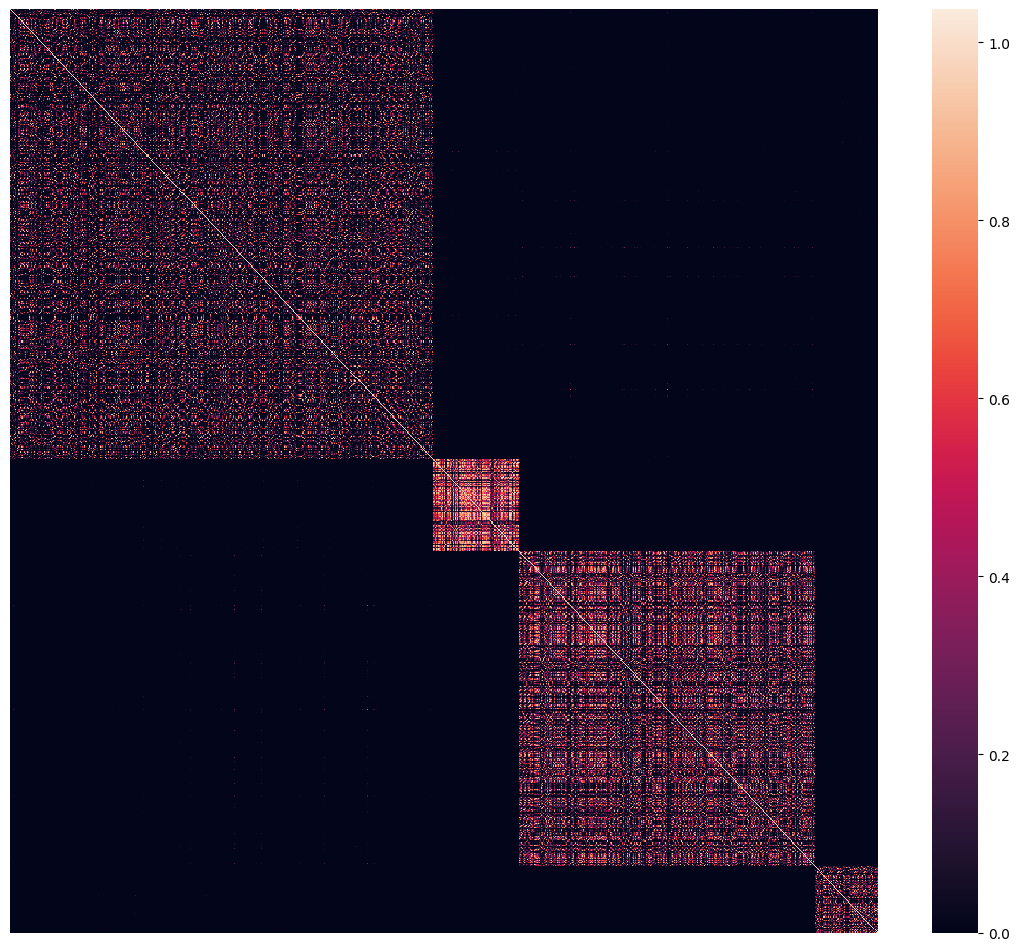

In [24]:
plt.figure(figsize=(14,12))

sns.heatmap(K_adp, cbar=True)
plt.axis('off')
plt.show()

In [27]:
X,y = open_dataset('2d-4c-no4')

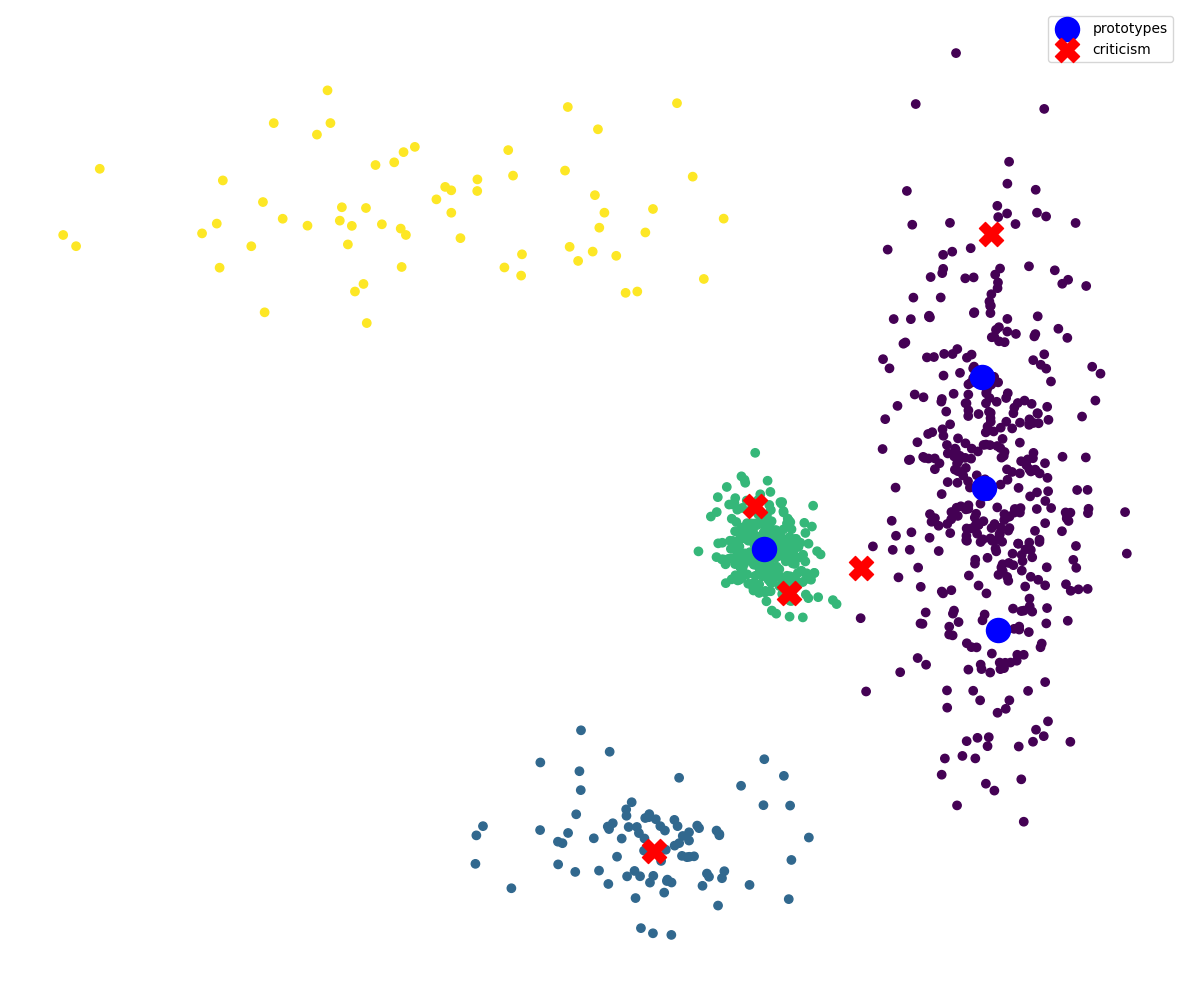

In [28]:
n = len(np.unique(y))
MMD = MMDCritic(X,adaptive_rbf_kernel)
k_proto = MMD.select_prototypes(n, np.arange(len(X)))
k_criti = MMD.select_criticisms(n+1, X[k_proto], train_indices = np.arange(len(X)), argMax = True)
plt.figure(figsize=(12,10))
plt.scatter(X[:,0],X[:,1], alpha = 1, c=y)
plt.scatter(X[k_proto,0],X[k_proto,1], c='b', s = 300, label='prototypes')
plt.scatter(X[k_criti,0],X[k_criti,1], c='red', marker='X', s = 300, label='criticism')
plt.legend()
plt.axis('off')
plt.tight_layout()
# plt.savefig('/projects/sig/vblase/image_AK/AK_proto_criti.png', format='png', dpi=300)
plt.show()

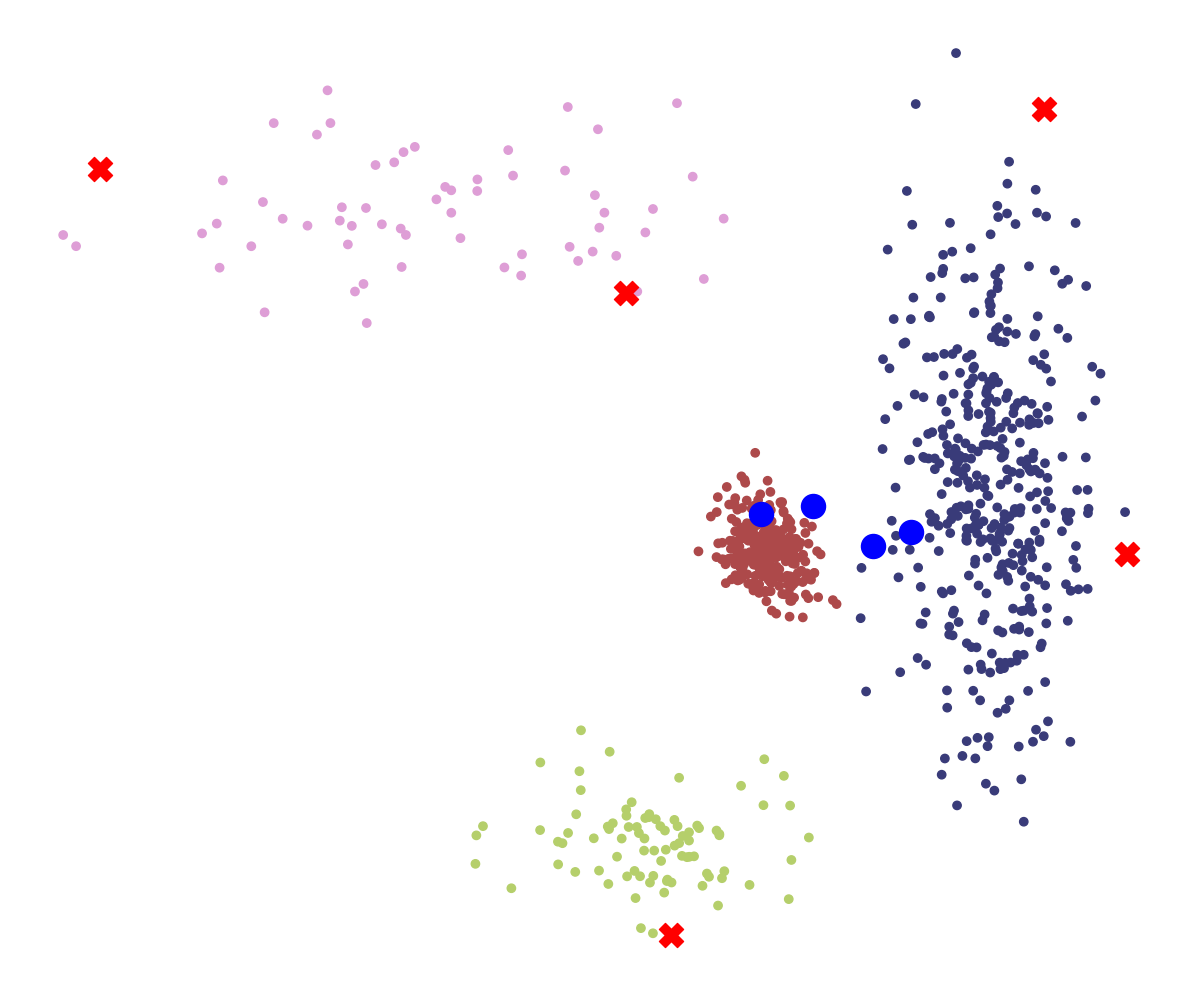

In [30]:
sigma = np.sqrt(np.median(pairwise_distances(X,X))) 

MMD = MMDCritic(X,RBFKernel(sigma))
k_proto = MMD.select_prototypes(n, np.arange(len(X)))
k_criti = MMD.select_criticisms(n+1, X[k_proto], train_indices = np.arange(len(X)), argMax = True)

plt.figure(figsize=(12,10))
plt.scatter(X[:,0],X[:,1], alpha = 1, c=y, cmap = 'tab20b')
plt.scatter(X[k_proto,0],X[k_proto,1], c='b', s = 300, label='prototypes')
plt.scatter(X[k_criti,0],X[k_criti,1], c='red', marker='X', s = 300, label='criticism')
plt.legend()
plt.axis('off')
plt.legend('',frameon=False)
plt.tight_layout()
# plt.savefig('/projects/sig/vblase/image_AK/GlobalK_proto_criti.png', format='png', dpi=300)
plt.show()